Aim : To develop a model that can accurately classify aircraft damage from images

Task 1: Create a valid_generator using the valid_datagen object
Task 2: Create a test_generator using the test_datagen object
Task 3: Load the VGG16 model
Task 4: Compile the model
Task 5: Train the model
Task 6: Plot accuracy curves for training and validation sets
Task 7: Visualizing the results
Task 8: Implement a Helper Function to Use the Custom Keras Layer
Task 9: Generate a caption for an image using the using BLIP pretrained model
Task 10: Generate a summary of an image using BLIP pretrained model

In [6]:
!{sys.executable} -m pip install transformers

  Using cached transformers-5.10.2-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.18.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2026.5.9-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.26.7-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached transformers-5.10.2-py3-none-any.whl (11.0 MB)
Using cached huggingface_hub-1.18.0-py3-none-any.whl (684 kB)
Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl (4.0 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached typer-0.25.1-py3-none-any.whl (58 kB)
Usin

In [10]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import zipfile
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image
import random
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
batch_size = 32
n_epochs = 5
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

Extracting the database

In [12]:
import tarfile
import urllib.request
import os
import shutil
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZjXM4RKxlBK9__ZjHBLl5A/aircraft-damage-dataset-v1.tar"

tar_filename = "aircraft_damage_dataset_v1.tar"
extracted_folder = "aircraft_damage_dataset_v1"  

urllib.request.urlretrieve(url, tar_filename)
print(f"Downloaded {tar_filename}. Extraction will begin now.")

if os.path.exists(extracted_folder):
    print(f"The folder '{extracted_folder}' already exists. Removing the existing folder.")
 
    shutil.rmtree(extracted_folder)
    print(f"Removed the existing folder: {extracted_folder}")

with tarfile.open(tar_filename, "r") as tar_ref:
    tar_ref.extractall()  
    print(f"Extracted {tar_filename} successfully.")
# Define directories for train, test, and validation splits
extract_path = "aircraft_damage_dataset_v1"
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')
valid_dir = os.path.join(extract_path, 'valid')

Downloaded aircraft_damage_dataset_v1.tar. Extraction will begin now.
The folder 'aircraft_damage_dataset_v1' already exists. Removing the existing folder.
Removed the existing folder: aircraft_damage_dataset_v1
Extracted aircraft_damage_dataset_v1.tar successfully.


In [13]:
# Create ImageDataGenerators to preprocess the data
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_rows, img_cols),   # Resize images to the size VGG16 expects
    batch_size=batch_size,
    seed = seed_value,
    class_mode='binary',
    shuffle=True # Binary classification: dent vs crack
)

Found 300 images belonging to 2 classes.


Task 1: Create valid_generator using valid_datagen object

In [14]:
valid_generator =  valid_datagen.flow_from_directory(
    directory= valid_dir,
    class_mode= 'binary',
    seed=seed_value,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows,img_cols)
)

Found 96 images belonging to 2 classes.


Task 2: Create a test_generator using the test_datagen object

In [15]:
test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    class_mode='binary',
    seed=seed_value,
    batch_size=batch_size,
    shuffle=False,
    target_size=(img_rows,img_cols)
)

Found 50 images belonging to 2 classes.


Task 3: Load the pre-trained model VGG16

In [16]:

base_model = VGG16(weights='imagenet',include_top=False,input_shape=(img_rows, img_cols, 3))
output = base_model.layers[-1].output
output = keras.layers.Flatten()(output)
base_model = Model(base_model.input, output)

for layer in base_model.layers:
    layer.trainable = False
# Build the custom model
model = Sequential()
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


Task 4: Compile the model

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Task 5: Model Training

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 89s 8s/step - accuracy: 0.5367 - loss: 0.7201 - val_accuracy: 0.6042 - val_loss: 0.6338
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 85s 9s/step - accuracy: 0.7233 - loss: 0.5536 - val_accuracy: 0.6979 - val_loss: 0.5823
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - accuracy: 0.7767 - loss: 0.4737 - val_accuracy: 0.7188 - val_loss: 0.5509
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 8s/step - accuracy: 0.8100 - loss: 0.4135 - val_accuracy: 0.6667 - val_loss: 0.6491
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 8s/step - accuracy: 0.8700 - loss: 0.3211 - val_accuracy: 0.6875 - val_loss: 0.5084


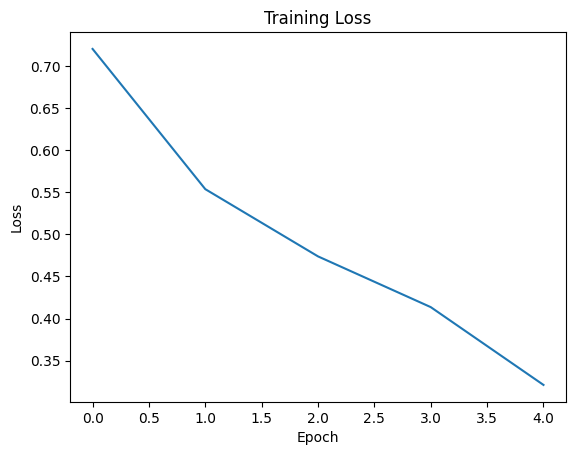

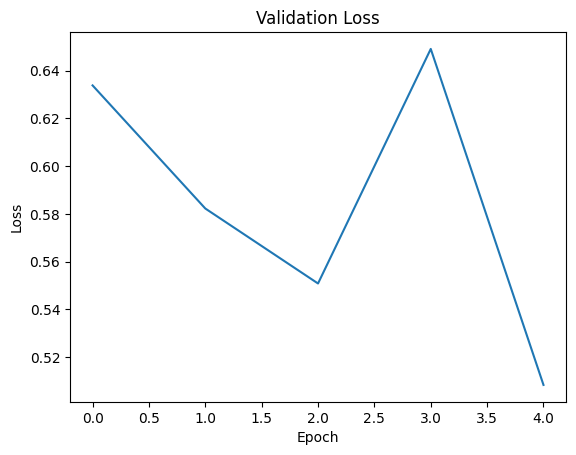

In [18]:
history = model.fit(
    train_generator,
    epochs=n_epochs, 
    validation_data=valid_generator, 
)
train_history = model.history.history 
# Plot the loss for both training and validation
plt.title("Training Loss")
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['loss'])
plt.show()

plt.title("Validation Loss")
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['val_loss'])
plt.show()

Task 6: Plot accuracy curves for training and validation sets

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.6875 - loss: 0.7371
Test Loss: 0.7371
Test Accuracy: 0.6875


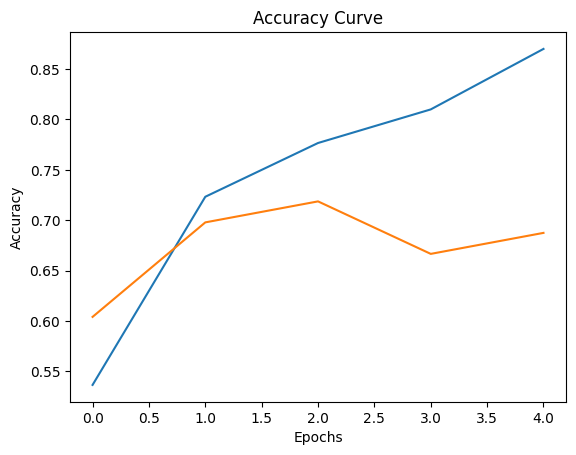

In [19]:
figsize=(5, 5)
plt.plot(train_history['accuracy'], label='Training Accuracy')
plt.plot(train_history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Function to plot a single image and its prediction
def plot_image_with_title(image, model, true_label, predicted_label, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    # Convert labels from one-hot to class indices if needed, but for binary labels it's just 0 or 1
    true_label_name = class_names[true_label]  # Labels are already in class indices
    pred_label_name = class_names[predicted_label]  # Predictions are 0 or 1

    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}")
    plt.axis('off')
    plt.show()

# Function to test the model with images from the test set
def test_model_on_image(test_generator, model, index_to_plot=0):
    # Get a batch of images and labels from the test generator
    test_images, test_labels = next(test_generator)

    # Make predictions on the batch
    predictions = model.predict(test_images)

    # In binary classification, predictions are probabilities (float). Convert to binary (0 or 1)
    predicted_classes = (predictions > 0.5).astype(int).flatten()

    # Get the class indices from the test generator and invert them to get class names
    class_indices = test_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}  # Invert the dictionary

    # Specify the image to display based on the index
    image_to_plot = test_images[index_to_plot]
    true_label = test_labels[index_to_plot]
    predicted_label = predicted_classes[index_to_plot]

    # Plot the selected image with its true and predicted labels
    plot_image_with_title(image=image_to_plot, model=model, true_label=true_label, predicted_label=predicted_label, class_names=class_names)




Task 7: Visualising the results

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


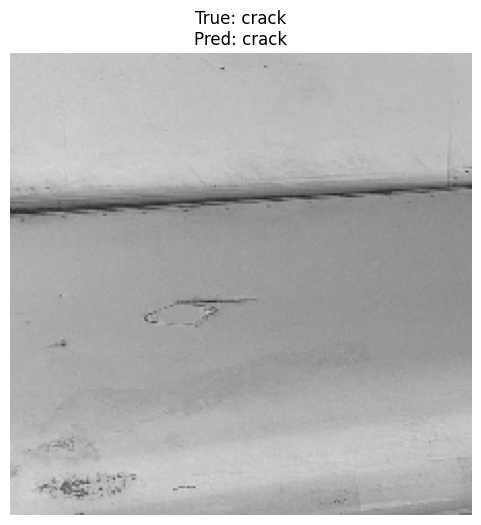

In [20]:
test_model_on_image(test_generator, model, index_to_plot=1)

In [21]:
#Load the required libraries
import torch
import tensorflow as tf
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

#load the pretrained BLIP processor and model:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

class BlipCaptionSummaryLayer(tf.keras.layers.Layer):
    def __init__(self, processor, model, **kwargs):
        """
        Initialize the custom Keras layer with the BLIP processor and model.

        Args:
            processor: The BLIP processor for preparing inputs for the model.
            model: The BLIP model for generating captions or summaries.
        """
        super().__init__(**kwargs)
        self.processor = processor
        self.model = model

    def call(self, image_path, task):
        # Use tf.py_function to run the custom image processing and text generation
        return tf.py_function(self.process_image, [image_path, task], tf.string)

    def process_image(self, image_path, task):
        """
        Perform image loading, preprocessing, and text generation.

        Args:
            image_path: Path to the image file as a string.
            task: The type of task ("caption" or "summary").

        Returns:
            The generated caption or summary as a string.
        """
        try:
            # Decode the image path from the TensorFlow tensor to a Python string
            image_path_str = image_path.numpy().decode("utf-8")

            # Open the image using PIL and convert it to RGB format
            image = Image.open(image_path_str).convert("RGB")

            # Set the appropriate prompt based on the task
            if task.numpy().decode("utf-8") == "caption":
                prompt = "This is a picture of"  # Modify prompt for more natural output
            else:
                prompt = "This is a detailed photo showing"  # Modify for summary

            # Prepare inputs for the BLIP model
            inputs = self.processor(images=image, text=prompt, return_tensors="pt")

            # Generate text output using the BLIP model
            output = self.model.generate(**inputs)

            # Decode the output into a readable string
            result = self.processor.decode(output[0], skip_special_tokens=True)
            return result
        except Exception as e:
            # Handle errors during image processing or text generation
            print(f"Error: {e}")
            return "Error processing image"

        

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Task 8: Implement a Helper Function to Use the Custom Keras Layer

In [22]:
def generate_text(image_path, task):
    blip_layer = BlipCaptionSummaryLayer(processor, model)
    return blip_layer(image_path, task)
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")  # actual path of image
caption = generate_text(image_path, tf.constant("caption"))
print("Caption:", caption.numpy().decode("utf-8"))
summary = generate_text(image_path, tf.constant("summary"))
print("Summary:", summary.numpy().decode("utf-8"))

Caption: this is a picture of a plane
Summary: this is a detailed photo showing the engine of a boeing 747


Task 9: Generate a caption for an image using the using BLIP pretrained model

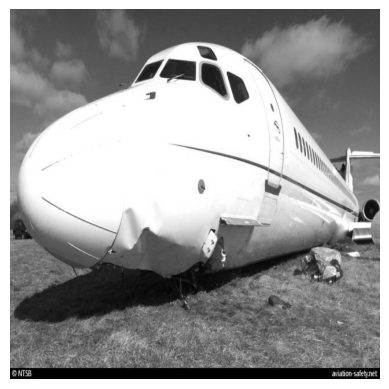

Error: [Errno 2] No such file or directory: '/content/sample_image.jpg'


<tf.Tensor: shape=(), dtype=string, numpy=b'Error processing image'>

In [23]:

image_url = "aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg"
img = plt.imread(image_url)
plt.imshow(img)
plt.axis('off')  
plt.show()

image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg")  
image_path = "/content/sample_image.jpg"  

import tensorflow as tf

image_tensor = tf.constant(image_path)
task_tensor = tf.constant("caption")

# Generate caption using your helper function
caption_output = generate_text(image_tensor, task_tensor)

# Display the caption
caption_output


Task 10: Generate a summary of an image using BLIP pretrained model

In [24]:
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg")  # actual path of image
task_tensor=tf.constant("caption")